In [2]:
!pip install pandas sqlalchemy pymysql

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")
from sqlalchemy import create_engine

In [4]:
print("Pandas version:", pd.__version__)

Pandas version: 2.3.3


In [10]:
import sqlalchemy

print("SQLAlchemy version:", sqlalchemy.__version__)

SQLAlchemy version: 2.0.43


In [11]:
import os

password = os.getenv("MYSQL_PASSWORD")

print(password is not None)

True


In [12]:
username = "root"
print(username)

root


In [13]:
password = os.getenv("MYSQL_PASSWORD")
print("Password loaded:", password is not None)

Password loaded: True


In [15]:
username = "root"                 
password = os.getenv("MYSQL_PASSWORD")
host = "localhost"                
port = 3306                       
database = "Black_Friday_Sales_Analysis"   

In [16]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="mysql+pymysql",
    username=username,
    password=password,
    host=host,
    port=port,
    database=database
)

engine = create_engine(connection_url)

print("SQLAlchemy engine created successfully!")

SQLAlchemy engine created successfully!


In [17]:
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print("Connection failed:")
    print(e)

Connection successful!


In [13]:
from sqlalchemy import inspect

inspector = inspect(engine)

tables = inspector.get_table_names()

print("Tables in database:")
print(tables)

Tables in database:
['black_friday_data']


In [21]:
query = "SELECT * FROM black_friday_data"

df = pd.read_sql(query, engine)

df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2


In [14]:
df.shape

(550068, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [16]:
# VALIDATING SCHEMA AND THE RECORD COUNT IN PYTHON---->

In [22]:
python_count = len(df)

print("Record count in Python:", python_count)

Record count in Python: 550068


In [23]:
count_query = """
SELECT COUNT(*) AS total_records
FROM black_friday_data;
"""

sql_count = pd.read_sql(count_query, engine)

sql_count

,total_records
0,550068


In [24]:
sql_record_count = sql_count["total_records"].iloc[0]

print("SQL record count:", sql_record_count)
print("Python record count:", python_count)
if sql_record_count == python_count:
    print("Validation successful: SQL and Python record counts match.")
else:
    print("Validation failed: Record counts do not match.")

SQL record count: 550068
Python record count: 550068
Validation successful: SQL and Python record counts match.


In [25]:
print(df.columns.tolist())

['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase', 'CLV', 'Category_Breadth', 'Stay_Years', 'City_Loyalty_Index', 'marital_status_label', 'city_tenure_num']


In [26]:
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
CLV                           float64
Category_Breadth                int64
Stay_Years                    float64
City_Loyalty_Index            float64
marital_status_label           object
city_tenure_num                 int64
dtype: object

In [27]:
print("===== DATA VALIDATION =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("\nColumn names:")
print(df.columns.tolist())

===== DATA VALIDATION =====
Rows: 550068
Columns: 18
Duplicate rows: 0

Column names:
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase', 'CLV', 'Category_Breadth', 'Stay_Years', 'City_Loyalty_Index', 'marital_status_label', 'city_tenure_num']


In [28]:
df_clean=df.copy()

In [29]:
# CHECKING MISSING VALUES---->

In [30]:
missing_values=df_clean.isnull().sum()
print("======== MISSING VALUES ========")
print(missing_values)

======== MISSING VALUES ========
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
CLV                           0
Category_Breadth              0
Stay_Years                    0
City_Loyalty_Index            0
marital_status_label          0
city_tenure_num               0
dtype: int64


In [31]:
df_clean.describe(include="object")

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years,marital_status_label
count,550068,550068,550068,550068,550068,550068
unique,3631,2,7,3,5,2
top,P00265242,M,26-35,B,1,Unmarried
freq,1880,414259,219587,231173,193821,324731


In [27]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
})
missing_summary

,Missing_Count,Missing_Percentage
User_ID,0,0.000000
Product_ID,0,0.000000
Gender,0,0.000000
Age,0,0.000000
Occupation,0,0.000000
City_Category,0,0.000000
Stay_In_Current_City_Years,0,0.000000
Marital_Status,0,0.000000
Product_Category_1,0,0.000000
Product_Category_2,173638,31.566643


In [28]:
# TREATING MISSING VALUES---->

In [29]:
df_clean["Product_Category_2"] = df_clean["Product_Category_2"].fillna(0)
df_clean["Product_Category_3"] = df_clean["Product_Category_3"].fillna(0)

In [32]:
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2


In [33]:
print(df_clean["Product_Category_2"].isnull().sum())
print(df_clean["Product_Category_3"].isnull().sum())

0
0


In [34]:
# CREATE CLV(CUSTOMER LIFETIME VALUE)---->

In [35]:
# customer total purchase-->
customer_total_purchase = (
    df_clean.groupby("User_ID")["Purchase"]
      .sum()
      .reset_index()
)
customer_total_purchase.head()

,User_ID,Purchase
0,1000001,334093
1,1000002,810472
2,1000003,341635
3,1000004,206468
4,1000005,821001


In [36]:
# number of transactions-->
number_of_transactions = (
    df_clean.groupby("User_ID")).size().reset_index(name="Number_of_Transactions")
number_of_transactions.head()

,User_ID,Number_of_Transactions
0,1000001,35
1,1000002,77
2,1000003,29
3,1000004,14
4,1000005,106


In [37]:
# customer summary-->
customer_summary = customer_total_purchase.merge(number_of_transactions,on="User_ID")
customer_summary.head()

,User_ID,Purchase,Number_of_Transactions
0,1000001,334093,35
1,1000002,810472,77
2,1000003,341635,29
3,1000004,206468,14
4,1000005,821001,106


In [38]:
print("Minimum Purchase:", df_clean["Purchase"].min())
print("Maximum Purchase:", df_clean["Purchase"].max())
print("Zero Purchases:", (df_clean["Purchase"] == 0).sum())
print("Negative Purchases:", (df_clean["Purchase"] < 0).sum())

Minimum Purchase: 12
Maximum Purchase: 23961
Zero Purchases: 0
Negative Purchases: 0


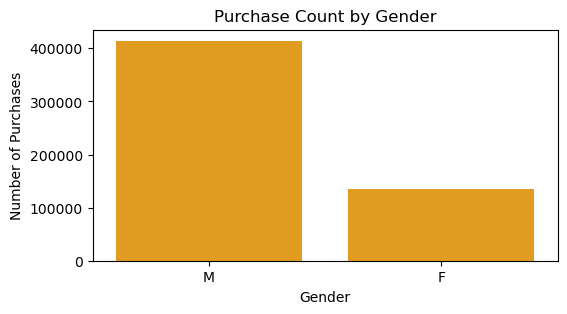

In [39]:
# PURCHASE BY GENDER---->
gender_counts = df_clean["Gender"].value_counts()
plt.figure(figsize=(6, 3))
sns.barplot(x=gender_counts.index, y=gender_counts.values,color="orange")
plt.title("Purchase Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Purchases")
plt.show()

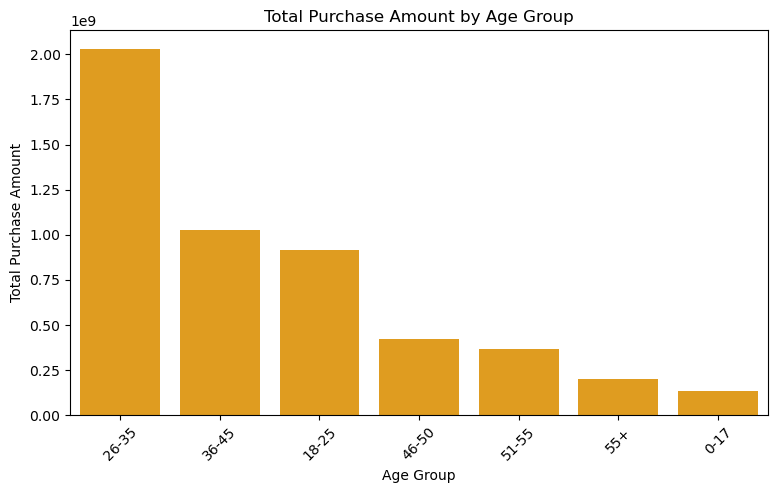

In [40]:
# PURCHASE BY AGE---->
age_purchase = df_clean.groupby("Age")["Purchase"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=age_purchase.index, y=age_purchase.values,color="orange")
plt.title("Total Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Purchase Amount")
plt.xticks(rotation=45)
plt.show()

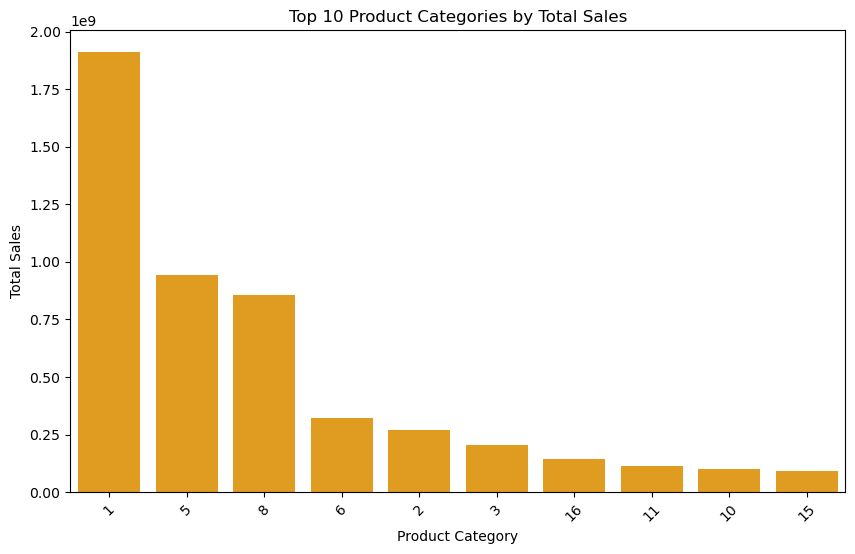

In [41]:
# SALES BY PRODUCT CATEGORY---->
category_sales = (df_clean.groupby("Product_Category_1")["Purchase"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index.astype(str),y=category_sales.values,color="orange")
plt.title("Top 10 Product Categories by Total Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

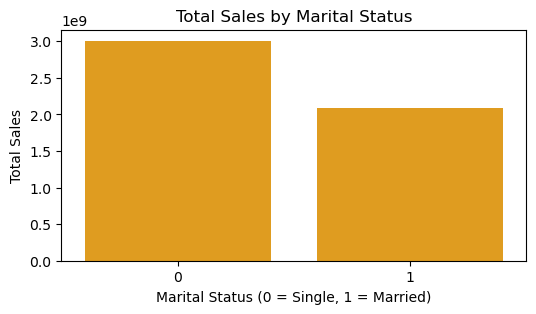

In [42]:
# SALES BY MARITAL STATUS---->
marital_sales = df_clean.groupby("Marital_Status")["Purchase"].sum()
plt.figure(figsize=(6, 3))
sns.barplot(
x=marital_sales.index.astype(str),
y=marital_sales.values,color="orange"
)
plt.title("Total Sales by Marital Status")
plt.xlabel("Marital Status (0 = Single, 1 = Married)")
plt.ylabel("Total Sales")
plt.show()

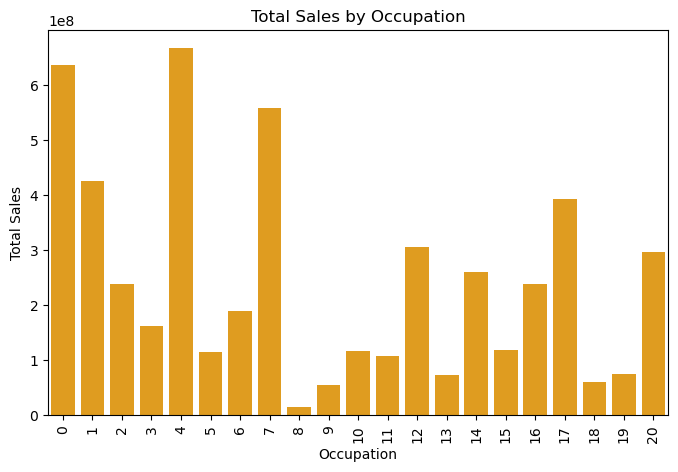

In [43]:
# TOTAL SALES BY OCCUPATION---->
occupation_sales = df_clean.groupby("Occupation")["Purchase"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(
x=occupation_sales.index,
y=occupation_sales.values,color="orange")
plt.title("Total Sales by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

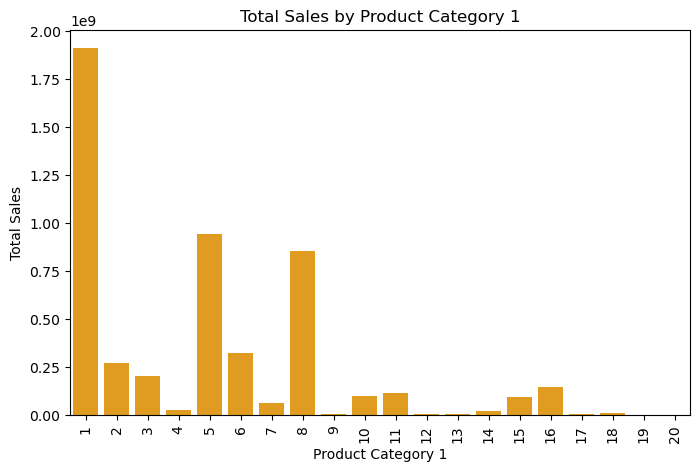

In [44]:
# TOTAL SALES BY PRODUCT CATEGORY 1---->
category1_sales = df_clean.groupby("Product_Category_1")["Purchase"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(
x=category1_sales.index,
y=category1_sales.values,color="orange"
)
plt.title("Total Sales by Product Category 1")
plt.xlabel("Product Category 1")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

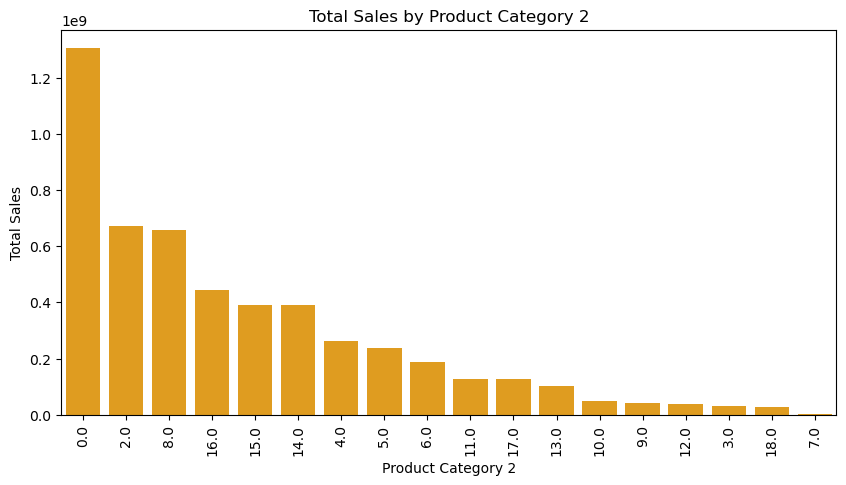

In [45]:
# TOTAL SALES BY PRODUCT CATEGORY 2---->
category2_sales = df_clean.groupby("Product_Category_2")["Purchase"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(
x=category2_sales.index.astype(str),
y=category2_sales.values,color="orange"
)
plt.title("Total Sales by Product Category 2")
plt.xlabel("Product Category 2")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

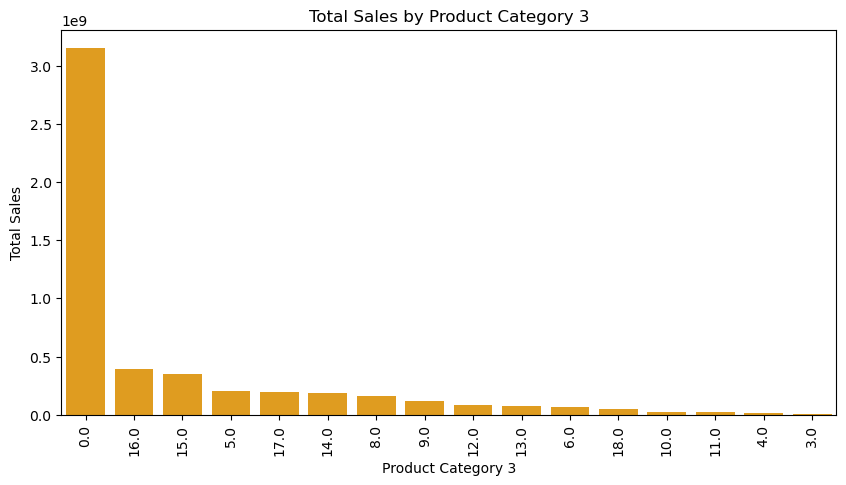

In [46]:
# TOTAL SALES BY PRODUCT CATEGORY 3---->
category3_sales = df_clean.groupby("Product_Category_3")["Purchase"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(
x=category3_sales.index.astype(str),
y=category3_sales.values,color="orange"
)
plt.title("Total Sales by Product Category 3")
plt.xlabel("Product Category 3")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

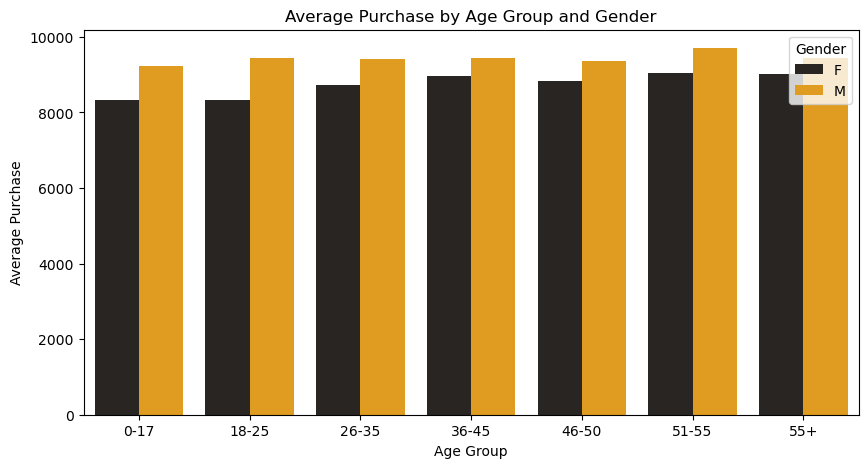

In [47]:
# AVERAGE PURCHASE BY AGE AND GENDER---->
age_gender_avg = df.groupby(["Age", "Gender"])["Purchase"].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(
data=age_gender_avg,
x="Age",
y="Purchase",
hue="Gender",color="orange"
)
plt.title("Average Purchase by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")
plt.show()

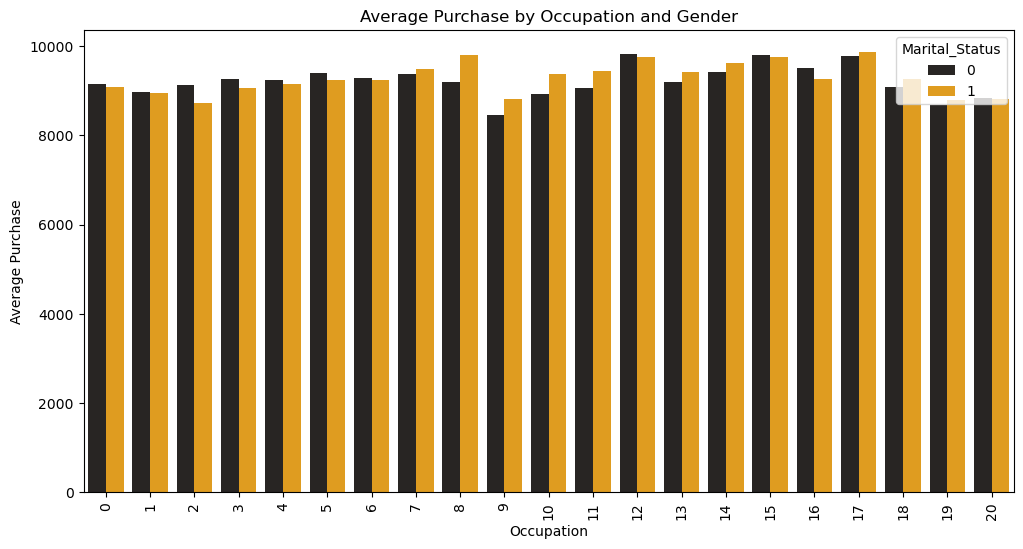

In [48]:
# AVERAGE PURCHASE BY OCCUPATION AND MARITAL STATUS---->
occupation_gender_avg = df.groupby(
["Occupation", "Marital_Status"]
)["Purchase"].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(
data=occupation_gender_avg,
x="Occupation",
y="Purchase",
hue="Marital_Status",color="orange"
)
plt.title("Average Purchase by Occupation and Gender")
plt.xlabel("Occupation")
plt.ylabel("Average Purchase")
plt.xticks(rotation=90)
plt.legend(title="Marital_Status")
plt.show()

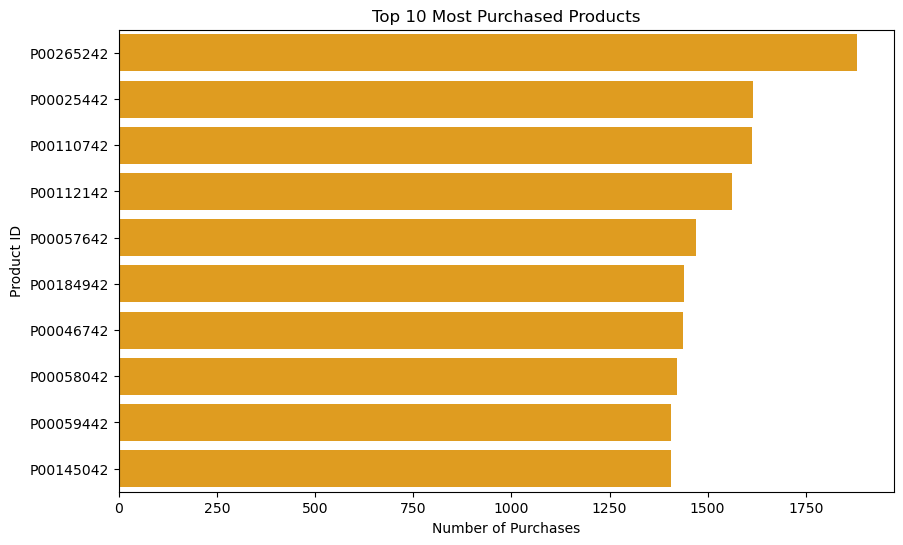

In [49]:
# TOP 10 MOST PURCHASED PRODUCTS---->
product_frequency = df_clean["Product_ID"].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=product_frequency.values,
    y=product_frequency.index, 
    color="orange"
)
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product ID")
plt.show()

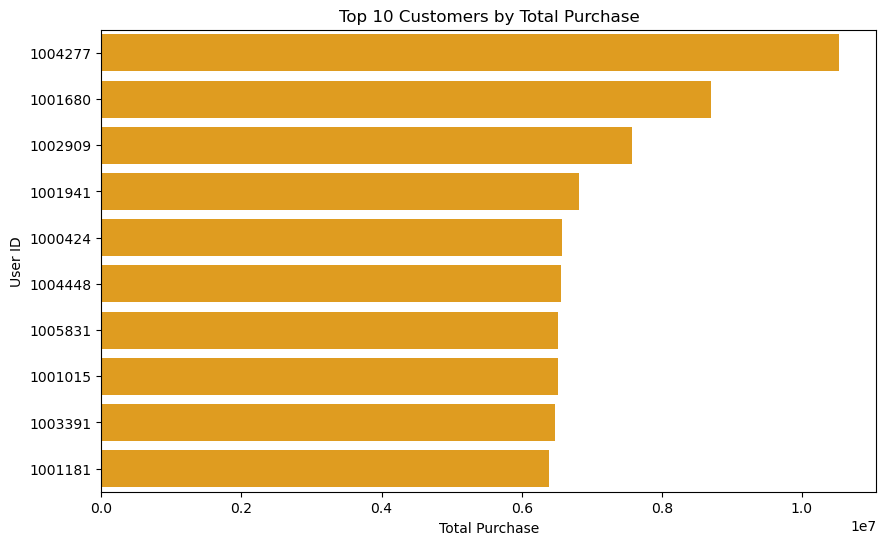

In [50]:
# TOP 10 CUSTOMER BY TOTAL PURCHASE---->
customer_sales = df_clean.groupby("User_ID")["Purchase"].sum().sort_values(ascending=False)
top_10_customers = customer_sales.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
x=top_10_customers.values,
y=top_10_customers.index.astype(str),color="orange"
)
plt.title("Top 10 Customers by Total Purchase")
plt.xlabel("Total Purchase")
plt.ylabel("User ID")
plt.show()

In [51]:
# CLV-->
customer_summary["CLV"] = (
    customer_summary["Purchase"] /
    customer_summary["Number_of_Transactions"]
)
customer_summary.head()

,User_ID,Purchase,Number_of_Transactions,CLV
0,1000001,334093,35,9545.514286
1,1000002,810472,77,10525.610390
2,1000003,341635,29,11780.517241
3,1000004,206468,14,14747.714286
4,1000005,821001,106,7745.292453


In [52]:
customer_summary.rename(
    columns={"Purchase": "Total_Purchase"},
    inplace=True
)
customer_summary.head()

,User_ID,Total_Purchase,Number_of_Transactions,CLV
0,1000001,334093,35,9545.514286
1,1000002,810472,77,10525.610390
2,1000003,341635,29,11780.517241
3,1000004,206468,14,14747.714286
4,1000005,821001,106,7745.292453


In [53]:
df_clean = df_clean.merge(
    customer_summary[["User_ID", "CLV"]],
    on="User_ID",
    how="left"
)

In [54]:
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV_x,Category_Breadth,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num,CLV_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286


In [55]:
# CATEGORY BREADTH---->

In [56]:
category_columns = [
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3"
]

In [57]:
df_clean.head(
)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV_x,Category_Breadth,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num,CLV_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286


In [58]:
def count_unique_categories(group):
    categories = set()
    
    for col in category_columns:
        categories.update(group[col].dropna().unique())
    
    categories.discard(0)
    
    return len(categories)

In [59]:
category_breadth = (df_clean.groupby("User_ID").apply(count_unique_categories).reset_index(name = "Category_Breadth"))

In [60]:
category_breadth.head()

,User_ID,Category_Breadth
0,1000001,14
1,1000002,15
2,1000003,11
3,1000004,11
4,1000005,16


In [61]:
df_clean = df_clean.merge(
    category_breadth,
    on="User_ID",
    how="left"
)
df_clean

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV_x,Category_Breadth_x,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num,CLV_y,Category_Breadth_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006040,P00331042,M,26-35,6,B,2,0,5,8.0,0.0,7058,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550064,1006040,P00331942,M,26-35,6,B,2,0,5,0.0,0.0,3581,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550065,1006040,P00343042,M,26-35,6,B,2,0,5,18.0,0.0,6915,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550066,1006040,P00346242,M,26-35,6,B,2,0,1,15.0,0.0,15358,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18


In [62]:
# CITY LOYALTY INDEX---->

In [63]:
df_clean["Stay_In_Current_City_Years"].value_counts()

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

In [64]:
df_clean["Stay_Years"] = (
    df_clean["Stay_In_Current_City_Years"]
    .replace("4+", "4")
    .astype(float)
)
df_clean

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV_x,Category_Breadth_x,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num,CLV_y,Category_Breadth_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006040,P00331042,M,26-35,6,B,2,0,5,8.0,0.0,7058,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550064,1006040,P00331942,M,26-35,6,B,2,0,5,0.0,0.0,3581,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550065,1006040,P00343042,M,26-35,6,B,2,0,5,18.0,0.0,6915,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18
550066,1006040,P00346242,M,26-35,6,B,2,0,1,15.0,0.0,15358,9184.994444,18,2.0,18369.988889,Unmarried,2,9184.994444,18


In [65]:
customer_average_purchase = df_clean.groupby("User_ID")["Purchase"].mean().reset_index(name = "Avg_Purchase")
customer_average_purchase.head()

,User_ID,Avg_Purchase
0,1000001,9545.514286
1,1000002,10525.610390
2,1000003,11780.517241
3,1000004,14747.714286
4,1000005,7745.292453


In [66]:
customer_stay = df_clean.groupby("User_ID")["Stay_Years"].first().reset_index()
customer_stay.head()

,User_ID,Stay_Years
0,1000001,2.0
1,1000002,4.0
2,1000003,3.0
3,1000004,2.0
4,1000005,1.0


In [67]:
city_loyalty = customer_average_purchase.merge(customer_stay,on = "User_ID")
city_loyalty.head()

,User_ID,Avg_Purchase,Stay_Years
0,1000001,9545.514286,2.0
1,1000002,10525.610390,4.0
2,1000003,11780.517241,3.0
3,1000004,14747.714286,2.0
4,1000005,7745.292453,1.0


In [68]:
# city loyalty index-->
city_loyalty["City_Loyalty_Index"] = city_loyalty["Avg_Purchase"] * city_loyalty["Stay_Years"]
city_loyalty.head()

,User_ID,Avg_Purchase,Stay_Years,City_Loyalty_Index
0,1000001,9545.514286,2.0,19091.028571
1,1000002,10525.610390,4.0,42102.441558
2,1000003,11780.517241,3.0,35341.551724
3,1000004,14747.714286,2.0,29495.428571
4,1000005,7745.292453,1.0,7745.292453


In [69]:
df_clean = df_clean.merge(city_loyalty[["User_ID","City_Loyalty_Index"]],on = "User_ID",how = "left")
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,...,Purchase,CLV_x,Category_Breadth_x,Stay_Years,City_Loyalty_Index_x,marital_status_label,city_tenure_num,CLV_y,Category_Breadth_y,City_Loyalty_Index_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,...,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14,19091.028571
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,...,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14,19091.028571
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,...,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14,19091.028571
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,...,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14,19091.028571
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,...,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14,19091.028571


In [70]:
if 'City_Loyalty_Index_y' in df_clean.columns:
    df_clean = df_clean.drop(columns='City_Loyalty_Index_y')
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV_x,Category_Breadth_x,Stay_Years,City_Loyalty_Index_x,marital_status_label,city_tenure_num,CLV_y,Category_Breadth_y
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2,9545.514286,14


In [82]:
df_clean.rename(columns={'City_Loyalty_Index_x': 'City_Loyalty_Index'}, inplace=True)
df_clean.rename(columns={'CLV_x': 'CLV'}, inplace=True)
df_clean.rename(columns={'Ctaegory_Breadth_x': 'Category_Breadth'}, inplace=True)
if 'Category_Breadth_y' in df_clean.columns:
    df_clean = df_clean.drop(columns='Category_Breadth_y')
df_clean.head()
if 'CLV_y' in df_clean.columns:
    df_clean = df_clean.drop(columns='CLV_y')
df_clean.rename(columns={'Ctaegory_Breadth_x': 'Category_Breadth'}, inplace=True)
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth_x,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2


In [83]:
new_features = ["CLV","Category_Breadth_x","Stay_Years","City_Loyalty_Index"]
df_clean[new_features].describe()

,CLV,Category_Breadth_x,Stay_Years,City_Loyalty_Index
count,550068.000000,550068.000000,550068.000000,550068.000000
mean,9263.968713,17.010401,1.858418,17251.441516
std,1619.510567,2.197323,1.289443,12515.865354
min,2318.733333,4.000000,0.000000,0.000000
25%,8141.850877,16.000000,1.000000,8523.526316
50%,9144.435484,18.000000,2.000000,14427.739910
75%,10186.360714,19.000000,3.000000,26873.939462
max,18577.893617,19.000000,4.000000,65961.866667


In [84]:
df_clean[new_features].isnull().sum()

CLV                   0
Category_Breadth_x    0
Stay_Years            0
City_Loyalty_Index    0
dtype: int64

In [85]:
# PERFORMING EDA WITH SEABORN AND MATPLOTLIB---->

In [86]:
sns.set_theme(style="whitegrid")

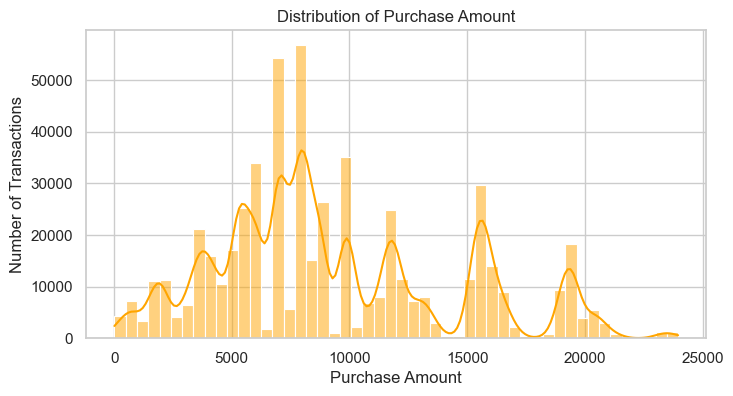

In [87]:
# Histogram for purchase distribution-->
plt.figure(figsize=(8, 4))
sns.histplot(
    df_clean["Purchase"],
    bins=50,
    kde=True,color="orange"
)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")
plt.show()

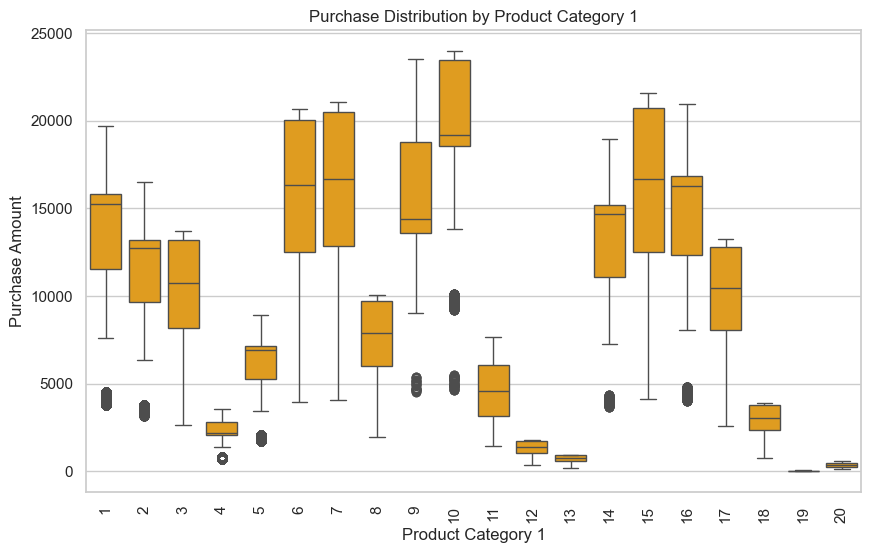

In [88]:
# PURCHASE DISTRIBUTION BY PRODUCT CATEGORY 1---->
plt.figure(figsize=(10, 6))
sns.boxplot(
data=df_clean,
x="Product_Category_1",
y="Purchase",color="orange"
)
plt.title("Purchase Distribution by Product Category 1")
plt.xlabel("Product Category 1")
plt.ylabel("Purchase Amount")
plt.xticks(rotation=90)
plt.show()

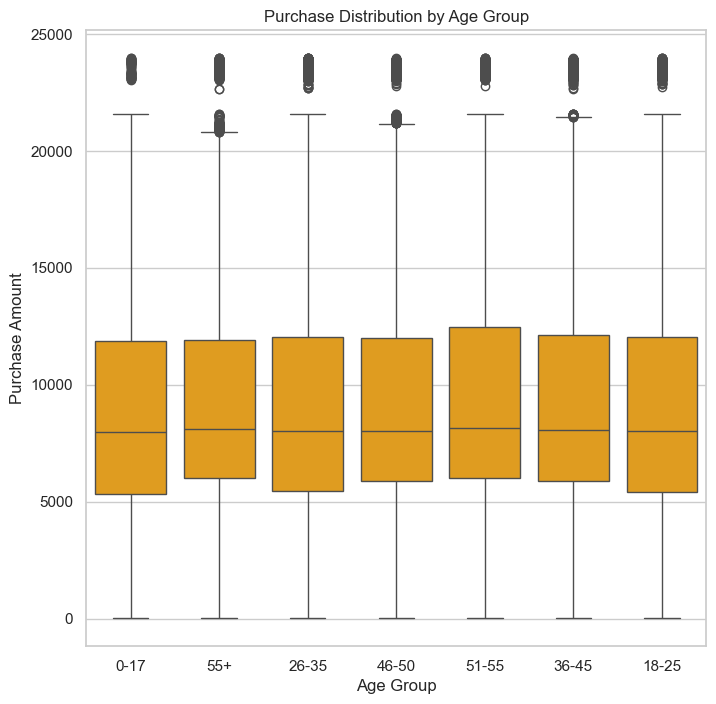

In [89]:
# Boxplots by age group, city, and marital status--->
# Boxplot by Age group-->
plt.figure(figsize=(8, 8))
sns.boxplot(
    data=df_clean,
    x="Age",
    y="Purchase",
    color="orange"
)
plt.title("Purchase Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.show()

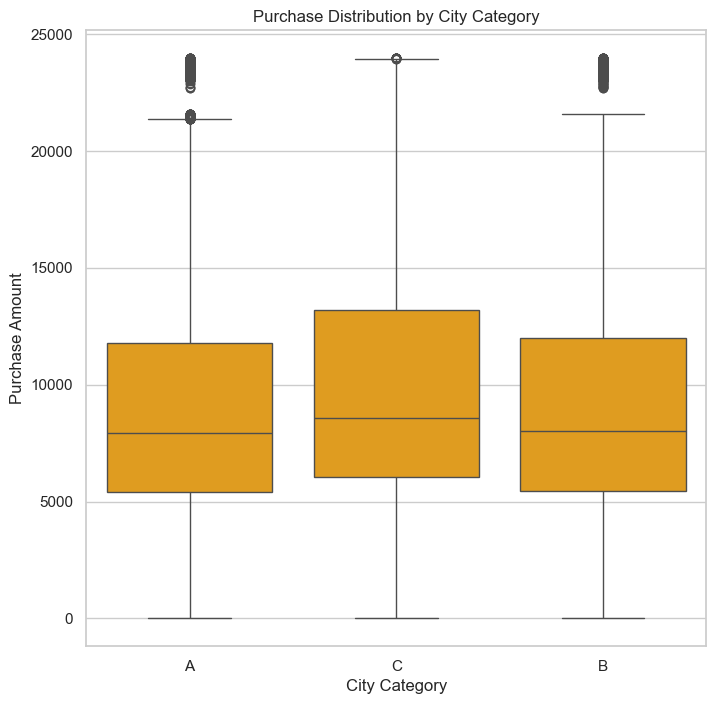

In [90]:
# Boxplot by City-->
plt.figure(figsize=(8, 8))
sns.boxplot(
    data=df_clean,
    x="City_Category",
    y="Purchase",
    color="orange"
)
plt.title("Purchase Distribution by City Category")
plt.xlabel("City Category")
plt.ylabel("Purchase Amount")
plt.show()

In [91]:
# Creating a readable label-->
df_clean["Marital_Status_Label"] = df_clean["Marital_Status"].map({
    0: "Unmarried",
    1: "Married"
})

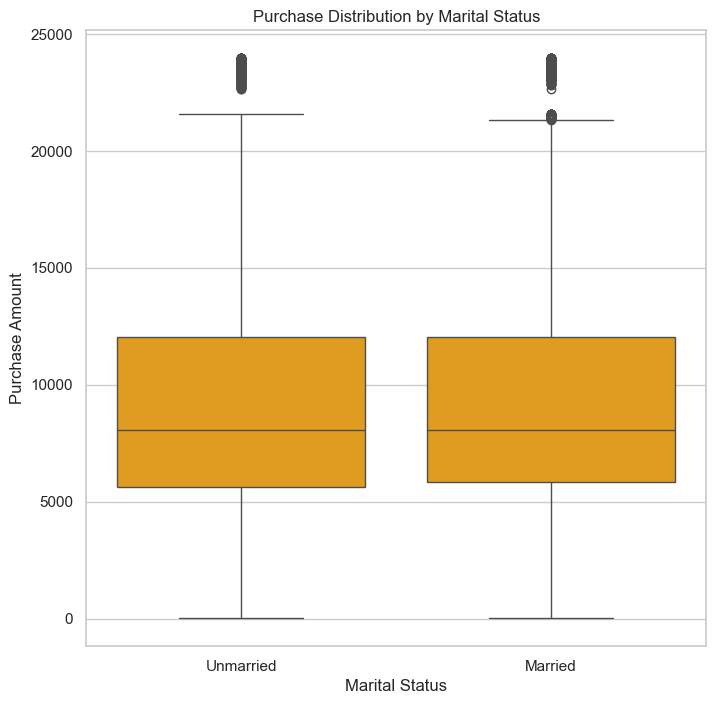

In [92]:
# Boxplot by Marital Status-->
plt.figure(figsize=(8, 8))
sns.boxplot(
    data=df_clean,
    x="Marital_Status_Label",
    y="Purchase",
    color="orange"
)
plt.title("Purchase Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Purchase Amount")
plt.show()

In [84]:
# Creating a Heatmaps to study correlations between demographics and purchase amounts--->
demographic_columns = [
    "Purchase",
    "Occupation",
    "Marital_Status",
    "Stay_Years"
]

demographic_corr = df_clean[demographic_columns].corr()

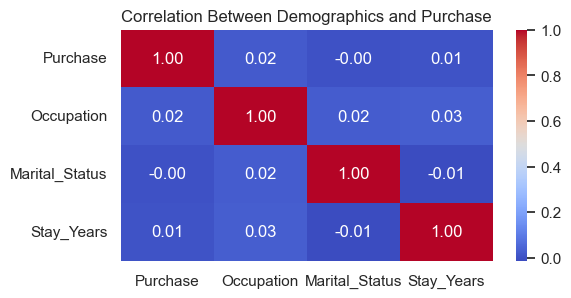

In [87]:
plt.figure(figsize=(6, 3))
sns.heatmap(
    demographic_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Demographics and Purchase")
plt.show()

In [ ]:
# STATISTICAL ANALYSIS IN PYTHON---->

In [93]:
# Performing the t-test gender wise--->
df_clean['Gender'].value_counts()

Gender
M    414259
F    135809
Name: count, dtype: int64

In [94]:
male_purchase = df_clean[df_clean['Gender'] == 'M']['Purchase']
female_purchase = df_clean[df_clean['Gender'] == 'F']['Purchase']
print(male_purchase)
print(female_purchase)

35         8257
36        19465
37         8017
38        11875
39         9824
          ...  
550063     7058
550064     3581
550065     6915
550066    15358
550067    16389
Name: Purchase, Length: 414259, dtype: int64
0         13650
1         13645
2         15416
3          9938
4          2849
          ...  
549883     8029
549884     6989
549885      490
549886     2153
549887    10688
Name: Purchase, Length: 135809, dtype: int64


In [96]:
print("Average Male Purchase:", male_purchase.mean())
print("Average Female Purchase:", female_purchase.mean())

Average Male Purchase: 9437.526040472265
Average Female Purchase: 8734.565765155476


In [97]:
# performing independent t-test by age-->
t_stat, p_value = stats.ttest_ind(
    male_purchase,
    female_purchase,
    equal_var=False
)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 46.358248669626064
P-value: 0.0


In [98]:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average purchase between genders.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average purchase between genders.")

Reject the null hypothesis.
There is a statistically significant difference in average purchase between genders.


In [99]:
# calculating a 95% confidence interval-->
mean_diff = male_purchase.mean() - female_purchase.mean()
print("Mean Difference:", mean_diff)

Mean Difference: 702.9602753167892


In [100]:
n1 = len(male_purchase)
n2 = len(female_purchase)

mean1 = male_purchase.mean()
mean2 = female_purchase.mean()

var1 = male_purchase.var()
var2 = female_purchase.var()

se = np.sqrt(var1/n1 + var2/n2)

df_cfd = (var1/n1 + var2/n2)**2 / (
    ((var1/n1)**2)/(n1-1) +
    ((var2/n2)**2)/(n2-1)
)
t_critical = stats.t.ppf(0.975, df_cfd)

ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print("====95% Confidence Interval====")
print("Low Purchase:", ci_lower)
print("High Purchase:", ci_upper)

====95% Confidence Interval====
Low Purchase: 673.2399199578947
High Purchase: 732.6806306756837


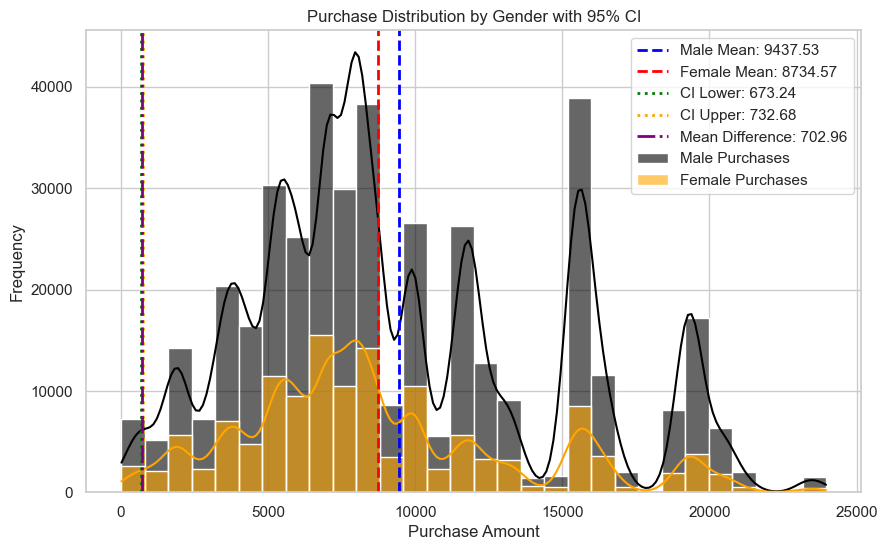

In [116]:
mean_male = male_purchase.mean()
mean_female = female_purchase.mean()

# Confidence interval bounds (from your earlier calculation)
ci_lower = 673.24
ci_upper = 732.68
mean_diff = 702.96

plt.figure(figsize=(10,6))

sns.histplot(male_purchase, bins=30, color='black', alpha=0.6, kde=True, label='Male Purchases')
sns.histplot(female_purchase, bins=30, color='orange', alpha=0.6, kde=True, label='Female Purchases')

plt.axvline(mean_male, color='blue', linestyle='--', linewidth=2, label=f'Male Mean: {mean_male:.2f}')
plt.axvline(mean_female, color='red', linestyle='--', linewidth=2, label=f'Female Mean: {mean_female:.2f}')

plt.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'CI Lower: {ci_lower:.2f}')
plt.axvline(ci_upper, color='orange', linestyle=':', linewidth=2, label=f'CI Upper: {ci_upper:.2f}')
plt.axvline(mean_diff, color='purple', linestyle='-.', linewidth=2, label=f'Mean Difference: {mean_diff:.2f}')

plt.title("Purchase Distribution by Gender with 95% CI")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [101]:
# performing t-test by marital status-->
df_clean['Marital_Status'].value_counts()

Marital_Status
0    324731
1    225337
Name: count, dtype: int64

In [102]:
married_purchase = df[df_clean['Marital_Status'] == 1]['Purchase']
unmarried_purchase = df[df_clean['Marital_Status'] == 0]['Purchase']
print(married_purchase)
print(unmarried_purchase)

141       19693
142       15852
143       11765
144       15485
145       19120
          ...  
549883     8029
549884     6989
549885      490
549886     2153
549887    10688
Name: Purchase, Length: 225337, dtype: int64
0         13650
1         13645
2         15416
3          9938
4          2849
          ...  
550063     7058
550064     3581
550065     6915
550066    15358
550067    16389
Name: Purchase, Length: 324731, dtype: int64


In [103]:
print("Average Married Purchase:", married_purchase.mean())
print("Average Unmarried Purchase:", unmarried_purchase.mean())

Average Married Purchase: 9261.174574082374
Average Unmarried Purchase: 9265.907618921507


In [104]:
t_stat, p_value = stats.ttest_ind(
    married_purchase,
    unmarried_purchase,
    equal_var=False
)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.34379905124865934
P-value: 0.7309975627344574


In [105]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("Statistically significant difference in purchase between marital-status groups.")
else:
    print("Fail to reject the null hypothesis")
    print("No statistically significant difference in purchase between marital-status groups.")

Fail to reject the null hypothesis
No statistically significant difference in purchase between marital-status groups.


In [105]:
# ANNOVA test to analyze differences accross age group-->
df_clean["Age"].value_counts()

Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

In [106]:
df_clean.groupby('Age')['Purchase'].agg(['count', 'mean', 'median'])

,count,mean,median
Age,,,
0-17,15102,8933.464640,7986.0
18-25,99660,9169.663606,8027.0
26-35,219587,9252.690633,8030.0
36-45,110013,9331.350695,8061.0
46-50,45701,9208.625697,8036.0
51-55,38501,9534.808031,8130.0
55+,21504,9336.280459,8105.5


In [107]:
# performing one way ANNOVA test-->
age_groups = [
    group['Purchase'].values
    for name, group in df_clean.groupby('Age')
]

In [108]:
f_stat, p_value = stats.f_oneway(*age_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average purchase across age groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average purchase across age groups.")

F-statistic: 40.57579909450407
P-value: 1.053563939251671e-49
Reject the null hypothesis.
There is a statistically significant difference in average purchase across age groups.


In [109]:
# ANNOVA to analize differences accross city categories-->
df_clean['City_Category'].value_counts()

City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

In [110]:
df_clean.groupby('City_Category')['Purchase'].agg(['count', 'mean', 'median'])

,count,mean,median
City_Category,,,
A,147720,8911.939216,7931.0
B,231173,9151.300563,8005.0
C,171175,9719.920993,8585.0


In [111]:
city_groups = [
    group['Purchase'].values
    for name, group in df_clean.groupby('City_Category')
]

In [113]:
f_stat_city, p_value_city = stats.f_oneway(*city_groups)

print("F-statistic:", f_stat_city)
print("P-value:", p_value_city)

if p_value_city < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in purchase across city categories.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in purchase across city categories.")

F-statistic: 1130.7459610102974
P-value: 0.0
Reject the null hypothesis.
There is a statistically significant difference in purchase across city categories.


In [ ]:
#  CORRELATION ANALYSIS--->

In [114]:
# city tenure vs purchase-->
df_clean['Stay_In_Current_City_Years'].value_counts()

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

In [115]:
df_clean['City_Tenure_Num'] = (
    df_clean['Stay_In_Current_City_Years']
    .replace('4+', 4)
    .astype(int)
)

In [117]:
df_clean.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth,Stay_Years,City_Loyalty_Index,Marital_Status_Label,City_Tenure_Num
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2


In [121]:
correlation, p_value = stats.pearsonr(
    df_clean['City_Tenure_Num'],
    df_clean['Purchase']
)
print("Correlation:", correlation)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Correlation: 0.005422295587475944
P-value: 5.7816177798810326e-05
The correlation is statistically significant.


In [120]:
# occupation analysis-->
df_clean.groupby('Occupation')['Purchase'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

,count,mean,median
Occupation,,,
17,40043,9821.478236,8635.0
12,31179,9796.640239,8569.0
15,12165,9778.891163,8513.0
8,1546,9532.592497,8419.5
14,27309,9500.702772,8122.0
7,59133,9425.728223,8069.0
16,25371,9394.464349,8070.0
5,12177,9333.149298,8080.0
13,7728,9306.351061,8090.5


In [122]:
# ANNOVA  occupation analysis-->(scipy.stats)-->
occupation_groups = [
    group['Purchase'].values
    for name, group in df_clean.groupby('Occupation')
]

In [123]:
f_stat, p_value_occ = stats.f_oneway(*occupation_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_occ)

if p_value_occ < 0.05:
    print("There is a statistically significant difference in purchase amounts across occupations.")
else:
    print("There is no statistically significant difference in purchase amounts across occupations.")

F-statistic: 98.47377546928168
P-value: 0.0
There is a statistically significant difference in purchase amounts across occupations.


In [124]:
# ANNOVA occupation analysis-->(statmodels)-->
model_occ = smf.ols(
    'Purchase ~ C(Occupation)',
    data=df_clean
).fit()
anova_occ = sm.stats.anova_lm(
    model_occ,
    typ=2
)
print(anova_occ)

                     sum_sq        df          F  PR(>F)
C(Occupation)  4.951671e+10      20.0  98.473775     0.0
Residual       1.382933e+13  550047.0        NaN     NaN


In [126]:
# combining city tenure,occupation,purchase-->
model = smf.ols(
    'Purchase ~ C(Occupation) + City_Tenure_Num',
    data=df_clean
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Purchase   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     94.20
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:21:06   Log-Likelihood:            -5.4671e+06
No. Observations:              550068   AIC:                         1.093e+07
Df Residuals:                  550046   BIC:                         1.093e+07
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            9096.2221    

In [67]:
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print("Connection failed:")
    print(e)

Connection successful!


In [68]:
df_clean.to_sql(
    name="black_friday_data",
    con=engine,
    if_exists="replace",
    index=False
)

550068

In [71]:
df_sql = pd.read_sql(
    "SELECT * FROM black_friday_data",
    con=engine
)
df_sql.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth,Stay_Years,City_Loyalty_Index
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571


In [72]:
df_clean.to_sql(
    name="black_friday_data",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method="multi"
)

550068

In [73]:
print(df_clean.columns.tolist())

['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase', 'CLV', 'Category_Breadth', 'Stay_Years', 'City_Loyalty_Index']


In [74]:
print([col for col in df.columns if 'marital' in col.lower()])
print([col for col in df.columns if 'tenure' in col.lower()])

['Marital_Status']
[]


In [75]:
df_clean['marital_status_label'] = df_clean['Marital_Status'].map({
    0: 'Unmarried',
    1: 'Married'
})

In [76]:
df_clean[['Marital_Status', 'marital_status_label']].head()

,Marital_Status,marital_status_label
0,0,Unmarried
1,0,Unmarried
2,0,Unmarried
3,0,Unmarried
4,0,Unmarried


In [77]:
df_clean['city_tenure_num'] = (
    df_clean['Stay_In_Current_City_Years']
    .replace('4+', 4)
    .astype(int)
)

In [78]:
df_clean[['Stay_In_Current_City_Years', 'city_tenure_num']].head()

,Stay_In_Current_City_Years,city_tenure_num
0,2,2
1,2,2
2,2,2
3,2,2
4,2,2


In [79]:
df_clean

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,CLV,Category_Breadth,Stay_Years,City_Loyalty_Index,marital_status_label,city_tenure_num
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650,9545.514286,14,2.0,19091.028571,Unmarried,2
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645,9545.514286,14,2.0,19091.028571,Unmarried,2
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416,9545.514286,14,2.0,19091.028571,Unmarried,2
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,0.0,9938,9545.514286,14,2.0,19091.028571,Unmarried,2
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,0.0,2849,9545.514286,14,2.0,19091.028571,Unmarried,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006040,P00331042,M,26-35,6,B,2,0,5,8.0,0.0,7058,9184.994444,18,2.0,18369.988889,Unmarried,2
550064,1006040,P00331942,M,26-35,6,B,2,0,5,0.0,0.0,3581,9184.994444,18,2.0,18369.988889,Unmarried,2
550065,1006040,P00343042,M,26-35,6,B,2,0,5,18.0,0.0,6915,9184.994444,18,2.0,18369.988889,Unmarried,2
550066,1006040,P00346242,M,26-35,6,B,2,0,1,15.0,0.0,15358,9184.994444,18,2.0,18369.988889,Unmarried,2


In [80]:
df_clean.to_sql(
    name='black_friday_data',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=5000,
    method='multi'
)

550068

In [69]:
category1_summary = df_clean.groupby("Product_Category_1")["Purchase"].agg(
Total_Sales="sum",
Average_Purchase="mean",
Number_of_Purchases="count"
).sort_values("Total_Sales", ascending=False)
print(category1_summary)

                    Total_Sales  Average_Purchase  Number_of_Purchases
Product_Category_1                                                    
1                    1910013754      13606.218596               140378
5                     941835229       6240.088178               150933
8                     854318799       7498.958078               113925
6                     324150302      15838.478550                20466
2                     268516186      11251.935384                23864
3                     204084713      10096.705734                20213
16                    145120612      14766.037037                 9828
11                    113791115       4685.268456                24287
10                    100837301      19675.570927                 5125
15                     92969042      14780.451828                 6290
7                      60896731      16365.689600                 3721
4                      27380488       2329.659491                11753
14    

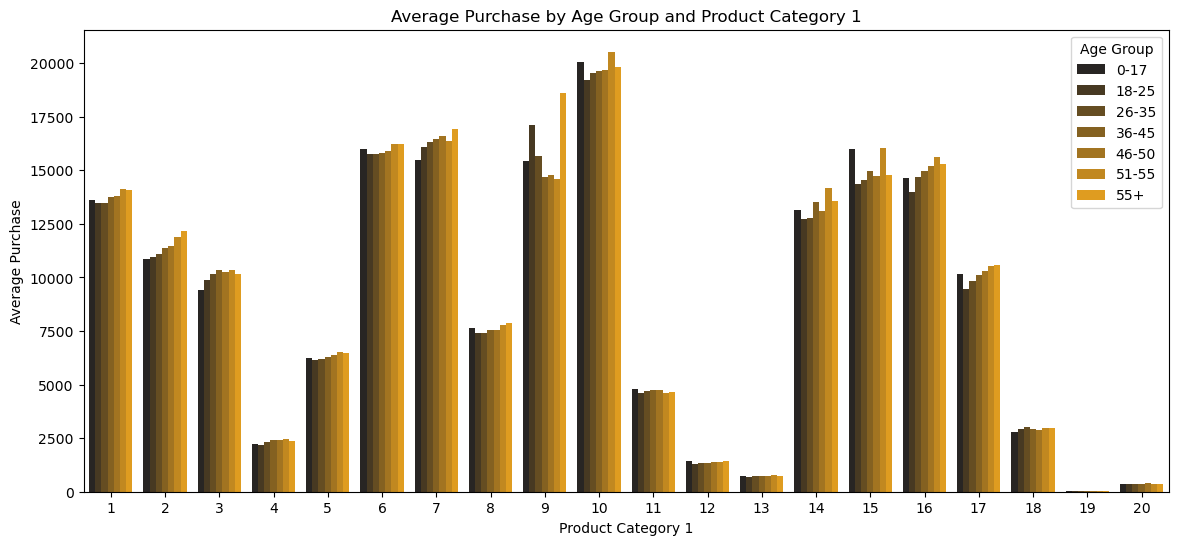

In [71]:
# AVERAGE PURCHASE BY AGE AND PRODUCT CATEGORY 1---->
avg_age_category = df_clean.groupby(["Age", "Product_Category_1"])["Purchase"].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(
data=avg_age_category,
x="Product_Category_1",
y="Purchase",
hue="Age",color="orange"
)
plt.title("Average Purchase by Age Group and Product Category 1")
plt.xlabel("Product Category 1")
plt.ylabel("Average Purchase")
plt.legend(title="Age Group")
plt.show()